In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('files/bank-additional_clean.csv', index_col=0)
df.head(3)

,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,id,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,empvarrate,conspriceidx,consconfidx,euribor3m,nremployed,y,date,latitude,longitude,contact_month,contact_year,age_cat
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,NaN,housemaid,married,basic 4y,No,No,No,telephone,261,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,2-agosto-2019,41.495,-71.233,agosto,2019.0,Adultos mayores
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,57.0,services,married,high school,NaN,No,No,telephone,149,1,NaN,0,nonexistent,1.1,93.994,-36.4,NaN,5191,no,14-septiembre-2016,34.601,-83.923,septiembre,2016.0,Mediana edad
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,37.0,services,married,high school,No,Si,No,telephone,226,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,15-febrero-2019,34.939,-94.847,febrero,2019.0,Adultos jóvenes


# Medidas posicion relativas:
- Percentiles: P30, P50 ...
- Cuartiles: Q1, Q2, Q3,Q4...
- Deciles: D1 (P10), D2 (P20)...

In [6]:
media_age = df['age'].mean()
mediana_age = df['age'].median()
moda_age =  df['age'].mode()[0]

print(f'media: {media_age}')
print(f'mediana: {mediana_age}')
print(f'moda: {moda_age}')



media: 39.97711193241816
mediana: 38.0
moda: 31.0


In [7]:
percentil_25_75 = np.percentile(df['age'].dropna(), [25, 75]) 
print(f'percentil 25: {percentil_25_75[0]}')
print(f'percentil 75: {percentil_25_75[1]}')

percentil 25: 32.0
percentil 75: 47.0


- el 25 % de los clientes tienen una edad igual o menor que 32 años y el 75% tienen menos o igual a 47 años. 

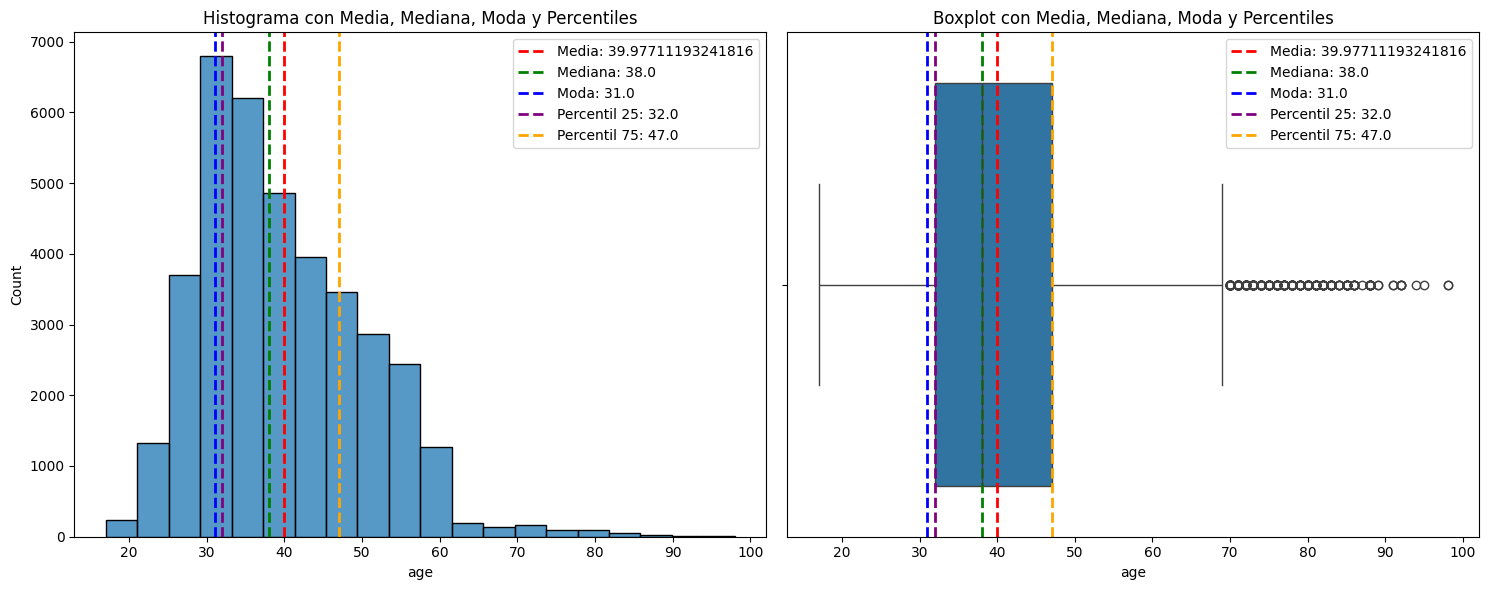

In [8]:
# Calcular los percentiles 25 y 75
percentile_25, percentile_75 = np.percentile(df['age'].dropna(), [25, 75])

# Crear la figura con subgráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualización 1: Histograma con Media, Mediana, Moda y Percentiles
sns.histplot(df['age'], bins=20, ax=axes[0])

# Añadir líneas de la media, mediana y moda
axes[0].axvline(media_age, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_age}')
axes[0].axvline(mediana_age, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_age}')
axes[0].axvline(moda_age, color='blue', linestyle='dashed', linewidth=2, label=f'Moda: {moda_age}')

# Añadir líneas para los percentiles
axes[0].axvline(percentile_25, color='purple', linestyle='dashed', linewidth=2, label=f'Percentil 25: {percentile_25}')
axes[0].axvline(percentile_75, color='orange', linestyle='dashed', linewidth=2, label=f'Percentil 75: {percentile_75}')

# Configurar leyenda y título
axes[0].legend()
axes[0].set_title('Histograma con Media, Mediana, Moda y Percentiles')

# Visualización 2: Boxplot con Media, Mediana, Moda y Percentiles
sns.boxplot(x=df['age'], ax=axes[1])

# Añadir líneas de la media, mediana y moda
axes[1].axvline(media_age, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_age}')
axes[1].axvline(mediana_age, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_age}')
axes[1].axvline(moda_age, color='blue', linestyle='dashed', linewidth=2, label=f'Moda: {moda_age}')

# Añadir líneas para los percentiles
axes[1].axvline(percentile_25, color='purple', linestyle='dashed', linewidth=2, label=f'Percentil 25: {percentile_25}')
axes[1].axvline(percentile_75, color='orange', linestyle='dashed', linewidth=2, label=f'Percentil 75: {percentile_75}')

# Configurar leyenda y título
axes[1].legend()
axes[1].set_title('Boxplot con Media, Mediana, Moda y Percentiles')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

## Cuartiles 


In [11]:
Q1, Q2, Q3 = np.percentile(df['income'], [25, 50, 75])
print(f'Q1: {Q1}, Q2: {Q2}, Q3: {Q3}')

Q1: 49610.0, Q2: 93050.5, Q3: 136744.5


- el 25% de las personas ganan menos 49610.0
- el 50% menos de 93050.5
- y el 75% menos de 136744.5
- el 50% de la personas gana entre 49610.0 y 136744.5 (entre Q1 y Q3)

## Deciles

In [ ]:
deciles = np.percentile(df['income'], [10, 20, 30, 40, 50, 60, 70, 80, 90])
deciles

## comparar muestras de la poblacion, analizar diferencias entre diferentes segmentos

array([ 23287.7,  40687.6,  58094.5,  75687.8,  93050.5, 110896.6,
       128462.3, 145397.8, 163206.4])

## Visualizacion con estadistica descriptiva: 

- Histograma:
    - distribución de los datos(siemtrica) 
    - densidad de los datos, frecuencia de los datos
    - extremos o dispersion en general 

- Boxplot:
    - Identificar los cuartiles, con el IQR
    - bigotes (valores máximos y minimos de los datos centrales, de los datos esperados)
    - valors atipicos (outliers)